# 📈 KRX Stock Prediction Ensemble Predictor (v3)

국내 주식(KRX) 데이터와 글로벌 거시경제 지표를 결합하여 향후 10영업일 뒤의 주가 방향성(상승/하락)을 예측하는 고성능 이종 앙상블(Ensemble) 인공지능 모델입니다.

기존 v2 모델의 한계를 보완하여 **레이블 단순화, 결측치(inf/nan) 완벽 처리, 무작위 포레스트 기반 피처 선택, LightGBM 하이퍼파라미터 자동 최적화(Optuna)**를 적용하여 예측 성능과 안정성을 극대화했습니다.

---

## 🚀 주요 개선사항 및 특징 (v2 → v3)

1. **이종 앙상블(Ensemble) 아키텍처 및 최적 가중치 반영**
   - **TensorFlow BiLSTM + Attention (30%)**: 시계열 데이터의 문맥을 양방향으로 파악하며, 어텐션 메커니즘을 통해 주가 변동의 핵심 시그널에 가중치를 부여합니다.
   - **LightGBM with Optuna (50%)**: 30회의 베이지안 최적화 탐색을 통해 최적의 하이퍼파라미터를 자동 도출하고, 수치 및 보조지표 간의 복잡한 상관관계를 초고속으로 학습합니다.
   - **Random Forest (20%)**: 트리 기반의 강건한 규제를 통해 과적합(Overfitting)을 방지하고 모델 전체의 하방 안정성을 확보합니다.

2. **고도화된 데이터 전처리 및 피처 엔지니어링**
   - **데이터 무결성 확보**: 데이터 정제 과정에서 발생하는 `inf`, `nan` 값을 완전히 제거 및 대체하여 데이터 누수(Data Leakage)를 방지했습니다.
   - **풍부한 피처 생성**: 기술적 보조지표(RSI, MACD, Stochastic, Bollinger Bands, ATR, OBV 등) 및 외인/기관 수급 데이터 자동 연산 지표 포함.
   - **RF 기반 피처 선택 (Feature Selection)**: 머신러닝 성능을 저하시키는 노이즈 피처를 `SelectFromModel`을 통해 걸러내어 핵심 피처만 모델에 주입합니다.

3. **검증 신뢰도 향상**
   - 시계열 데이터의 특성을 고려하여 과거 데이터로 순차적인 미래를 예측하는 **전진 분석 검증 (Walk-Forward Validation, 5-Fold)** 시스템을 탑재하여 실전 투자 환경과 유사한 검증을 수행합니다.

---

## 📂 프로젝트 구조

```text
├── local_pytorch_version/
│   ├── KRX_Ensemble_Predictor_v3.ipynb  # 🔥 최신 앙상블 실전 예측 주피터 노트북
│   └── lgbm_model_v3.txt                # Optuna로 최적화된 LightGBM 모델 가중치
├── (기존 구버전 파일들)
└── README.md

In [5]:
# =====================================================================
# 📦 Cell 1 & 2: 필수 패키지 설치 및 임포트
# =====================================================================
# 로컬 터미널에서 최신 GPU 인식을 위해 아래 명령어를 먼저 실행해 주세요.
%pip install pykrx ta scikit-learn lightgbm yfinance optuna matplotlib seaborn -q
%pip install --pre torch torchvision torchaudio --index-url https://download.pytorch.org/whl/nightly/cu128 --no-cache-dir
%pip install -U FinanceDataReader 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import warnings, pickle
warnings.filterwarnings('ignore')

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# 운영체제별 폰트 예외 처리 (Windows / Linux)
try:
    font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
    font_prop = fm.FontProperties(fname=font_path)
    plt.rcParams['font.family'] = font_prop.get_name()
except:
    plt.rcParams['font.family'] = 'Malgun Gothic'  # 로컬 윈도우 기본 폰트
plt.rcParams['axes.unicode_minus'] = False

from pykrx import stock
import yfinance as yf
from datetime import datetime, timedelta

from ta.momentum import RSIIndicator, StochasticOscillator
from ta.trend import MACD, EMAIndicator, SMAIndicator
from ta.volatility import BollingerBands, AverageTrueRange
from ta.volume import OnBalanceVolumeIndicator

from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import (accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, f1_score, roc_curve)
from sklearn.utils.class_weight import compute_class_weight
import lightgbm as lgb

# 🔥 PyTorch 핵심 컴포넌트 임포트
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

# 🔥 로컬 GPU(RTX 5060 Ti) 장치 고정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ PyTorch    : {torch.__version__}')
print(f'✅ LightGBM   : {lgb.__version__}')
print(f'✅ Optuna     : {optuna.__version__}')
print(f'✅ GPU Device : {device} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None"})')

# =====================================================================

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Looking in indexes: https://download.pytorch.org/whl/nightly/cu128
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
✅ PyTorch    : 2.12.0.dev20260408+cu128
✅ LightGBM   : 4.6.0
✅ Optuna     : 4.9.0
✅ GPU Device : cuda (NVIDIA GeForce RTX 5060 Ti)


ERROR: Could not find a version that satisfies the requirement FinanceDataReader (from versions: none)
ERROR: No matching distribution found for FinanceDataReader

[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



📌 미장종목  : NVDA
📅 기간      : 20150101 ~ 20260623
🔮 예측기간  : 3일 후 주가 방향
⚖️ 조정 가중치: LSTM(0.05) | LGBM(0.65) | RF(0.3)
📡 NVDA 야후 파이낸스 데이터 수집 중...
📡 글로벌 거시경제 변수(S&P500, VIX) 동기화 중...
✅ 데이터 수집 및 피처 엔지니어링 완료! (최종 데이터 셰이프: (2825, 15))
⚖️ 클래스 가중치 계산 완료: {0: np.float64(0.7683319903303787), 1: np.float64(1.4316816816816818)}

✅ PyTorch LSTM 모델 트레이닝 완료!

🔍 Optuna 기반 LightGBM 하이퍼파라미터 베이지안 탐색 중...
✅ LightGBM 최적화 완료! (Best AUC: 0.8324)
🌳 RandomForest 학습 프로세스 시작...
✅ RandomForest 최종 최적화 완료!

🎯 앙상블 시스템 결합 및 최종 예측 테스트 중...
  📋 [기아] 모델별 테스트 스코어 최종 스펙
  LSTM (PyTorch) | Acc=0.6355 | AUC=0.5000 | F1=0.0000
  LightGBM      | Acc=0.7131 | AUC=0.7687 | F1=0.6250
  RandomForest  | Acc=0.7052 | AUC=0.7515 | F1=0.6166
  🏆 앙상블 모델  | Acc=0.7092 | AUC=0.7671 | F1=0.6158


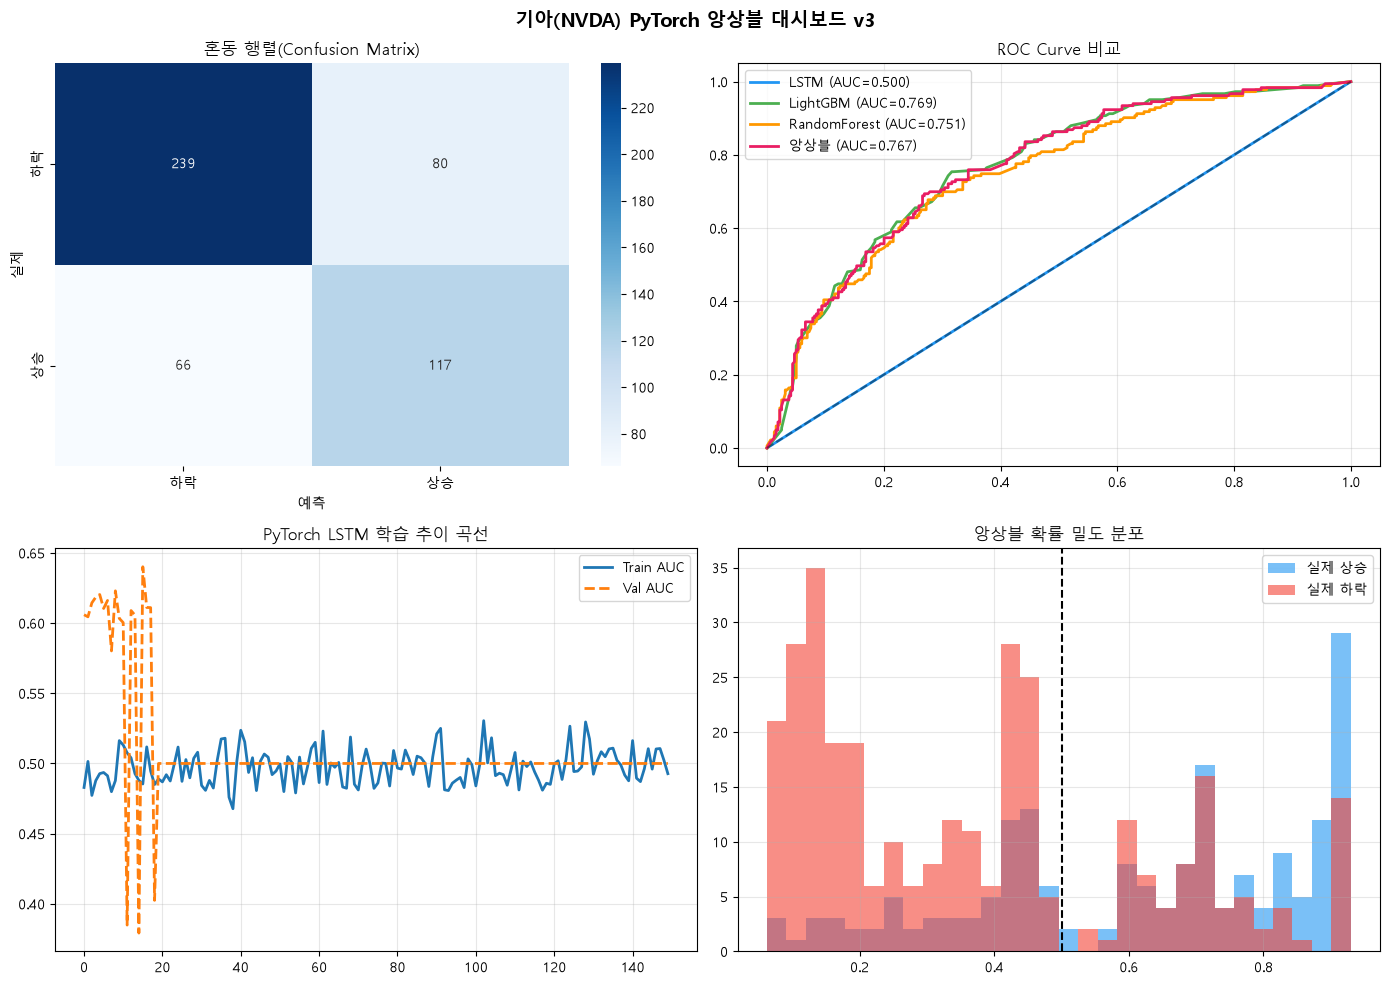


🔄 [보안 검증] 데이터 누수가 차단된 Walk-Forward 엔진 가동...
  Fold 2: Acc=0.7083  F1=0.6383  AUC=0.7861
  Fold 3: Acc=0.7010  F1=0.6494  AUC=0.7881
  Fold 4: Acc=0.6863  F1=0.6213  AUC=0.7633
  Fold 5: Acc=0.7083  F1=0.6490  AUC=0.7696

📊 [누수 차단 후 검증 결과] -> Acc: 0.7010 | F1: 0.6395 | AUC: 0.7768
📡 NVDA KRX 데이터 수집 중...
Error occurred in get_stock_name: 'NoneType' object is not subscriptable


ValueError: Length mismatch: Expected axis has 0 elements, new values have 5 elements

In [ ]:
# =====================================================================
# ⚙️ Cell 3: 설정값 지정
# =====================================================================
import time

TICKER     = '000270'  
START_DATE = '20150101'
END_DATE   = datetime.today().strftime('%Y%m%d')

SEQ_LEN       = 60
PRED_DAYS     = 3     
BATCH_SIZE    = 64
EPOCHS        = 150
LSTM_UNITS    = [128, 64]
DROPOUT       = 0.3
LEARNING_RATE = 0.001
TEST_RATIO    = 0.2
VAL_RATIO     = 0.1

# 앙상블 가중치 리밸런싱 (전체 합 = 1.0)
W_LSTM = 0.05
W_LGBM = 0.65
W_RF   = 0.30

print(f'\n📌 종목코드  : {TICKER}')
print(f'📅 기간      : {START_DATE} ~ {END_DATE}')
print(f'🔮 예측기간  : {PRED_DAYS}일 후 주가 방향')
print(f'⚖️ 조정 가중치: LSTM({W_LSTM}) | LGBM({W_LGBM}) | RF({W_RF})')

# =====================================================================
# 📥 Cell 4 & 5: 데이터 수집 및 피처 엔지니어링 (기존 로직 완전 유지)
# =====================================================================
def fetch_krx_data(ticker, start, end):
    print(f'📡 {ticker} KRX 데이터 수집 중...')
    name = stock.get_market_ticker_name(ticker)
    df = stock.get_market_ohlcv_by_date(start, end, ticker).iloc[:, :5]
    df.columns = ['Open','High','Low','Close','Volume']
    df.index = pd.to_datetime(df.index)
    try:
        trade = stock.get_market_trading_volume_by_date(start, end, ticker)
        if '외국인합계' in trade.columns: df['Foreign_Buy'] = trade['외국인합계']
        if '기관합계' in trade.columns: df['Inst_Buy'] = trade['기관합계']
    except:
        df['Foreign_Buy'], df['Inst_Buy'] = 0, 0
    df.dropna(inplace=True)
    return df, name

def fetch_external_data(start, end):
    print('📡 글로벌 거시경제 데이터 수집 중...')
    start_dt = pd.to_datetime(start, format='%Y%m%d').strftime('%Y-%m-%d')
    end_dt   = pd.to_datetime(end,   format='%Y%m%d').strftime('%Y-%m-%d')
    tickers = {'SP500':'^GSPC', 'VIX':'^VIX', 'DXY':'DX-Y.NYB', 'OIL':'CL=F'}
    ext = pd.DataFrame()
    for name, sym in tickers.items():
        try:
            ext[name] = yf.download(sym, start=start_dt, end=end_dt, progress=False)['Close']
        except:
            print(f'  ⚠️ {name} 다운로드 실패')
    ext.index = pd.to_datetime(ext.index)
    if isinstance(ext.columns, pd.MultiIndex):
        ext.columns = ext.columns.get_level_values(0)
    for col in list(ext.columns):
        ext[f'{col}_ret']  = ext[col].pct_change()
        ext[f'{col}_MA5']  = ext[col].pct_change().rolling(5).mean()
    ext.dropna(inplace=True)
    return ext

df_raw, stock_name = fetch_krx_data(TICKER, START_DATE, END_DATE)
df_ext = fetch_external_data(START_DATE, END_DATE)
df_merged = df_raw.join(df_ext, how='left').ffill().dropna()

def add_features(df):
    d = df.copy()
    d['Return'] = d['Close'].pct_change()
    for i in [2, 5, 10, 20]: d[f'Return_{i}d'] = d['Close'].pct_change(i)
    d['HL_ratio'] = (d['High'] - d['Low']) / d['Close']
    d['OC_ratio'] = (d['Close'] - d['Open']) / (d['Open'] + 1e-9)
    d['Gap'] = (d['Open'] - d['Close'].shift(1)) / (d['Close'].shift(1) + 1e-9)

    for w in [5, 10, 20, 60, 120]:
        sma = SMAIndicator(d['Close'], window=w).sma_indicator()
        d[f'SMA_{w}'] = sma
        d[f'SMA_dist_{w}'] = (d['Close'] - sma) / (sma + 1e-9)
    d['EMA_12'] = EMAIndicator(d['Close'], window=12).ema_indicator()
    d['EMA_26'] = EMAIndicator(d['Close'], window=26).ema_indicator()

    macd = MACD(d['Close'])
    d['MACD'], d['MACD_signal'], d['MACD_diff'] = macd.macd(), macd.macd_signal(), macd.macd_diff()
    for w in [7, 14, 21]: d[f'RSI_{w}'] = RSIIndicator(d['Close'], window=w).rsi()

    stoch = StochasticOscillator(d['High'], d['Low'], d['Close'])
    d['Stoch_k'], d['Stoch_d'] = stoch.stoch(), stoch.stoch_signal()
    bb = BollingerBands(d['Close'])
    d['BB_width'] = (bb.bollinger_hband() - bb.bollinger_lband()) / (bb.bollinger_mavg() + 1e-9)
    d['BB_pct'] = bb.bollinger_pband()

    for w in [7, 14]:
        d[f'ATR_{w}'] = AverageTrueRange(d['High'], d['Low'], d['Close'], window=w).average_true_range()
        d[f'ATR_{w}_norm'] = d[f'ATR_{w}'] / (d['Close'] + 1e-9)

    d['Volume_ratio'] = d['Volume'] / (d['Volume'].rolling(20).mean() + 1e-9)
    d['OBV'] = OnBalanceVolumeIndicator(d['Close'], d['Volume']).on_balance_volume()
    d['OBV_MA'] = d['OBV'].rolling(10).mean()
    d['OBV_dist'] = (d['OBV'] - d['OBV_MA']) / (d['OBV_MA'].abs() + 1e-9)

    d['Vol_5d'], d['Vol_20d'] = d['Return'].rolling(5).std(), d['Return'].rolling(20).std()
    d['Vol_ratio'] = d['Vol_5d'] / (d['Vol_20d'] + 1e-9)

    if 'Foreign_Buy' in d.columns:
        d['Foreign_MA5'], d['Foreign_MA20'] = d['Foreign_Buy'].rolling(5).mean(), d['Foreign_Buy'].rolling(20).mean()
    if 'Inst_Buy' in d.columns:
        d['Inst_MA5'], d['Inst_MA20'] = d['Inst_Buy'].rolling(5).mean(), d['Inst_Buy'].rolling(20).mean()

    threshold = 0.01  # 1%
    d['Future_Return'] = (d['Close'].shift(-PRED_DAYS) - d['Close']) / d['Close']
    d['Label'] = (d['Future_Return'] > threshold).astype(int)
    d.replace([np.inf, -np.inf], np.nan, inplace=True)
    return d.ffill().bfill().dropna()

df_feat = add_features(df_merged)

# =====================================================================
# ⚙️ Cell 6: 전처리, 스케일링 및 Random Forest 기반 피처 중요도 선택
# =====================================================================
exclude = ['Label','Open','High','Low','Close','Volume','Foreign_Buy','Inst_Buy','SP500','VIX','DXY','OIL']
feature_cols = [c for c in df_feat.columns if c not in exclude]

X_raw, y_raw = df_feat[feature_cols].values, df_feat['Label'].values
X_raw = np.where(np.isinf(X_raw), np.nan, X_raw)
X_raw = pd.DataFrame(X_raw, columns=feature_cols).ffill().bfill().values

n = len(X_raw)
test_size, val_size = int(n * TEST_RATIO), int(n * VAL_RATIO)
train_size = n - test_size - val_size

scaler = RobustScaler()
X_tr_sc = scaler.fit_transform(X_raw[:train_size])
X_vl_sc = scaler.transform(X_raw[train_size:train_size+val_size])
X_te_sc = scaler.transform(X_raw[train_size+val_size:])

y_train, y_val, y_test = y_raw[:train_size], y_raw[train_size:train_size+val_size], y_raw[train_size+val_size:]

rf_selector = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_selector.fit(X_tr_sc, y_train)
selector = SelectFromModel(rf_selector, threshold='mean', prefit=True)

X_tr_sel = selector.transform(X_tr_sc)
X_vl_sel = selector.transform(X_vl_sc)
X_te_sel = selector.transform(X_te_sc)
selected_cols = [feature_cols[i] for i in range(len(feature_cols)) if selector.get_support()[i]]

def make_sequences(X, y, seq_len):
    xs, ys = [], []
    for i in range(seq_len, len(X)):
        xs.append(X[i-seq_len:i])
        ys.append(y[i])
    return np.array(xs), np.array(ys)

X_tr, y_tr = make_sequences(X_tr_sel, y_train, SEQ_LEN)
X_vl, y_vl = make_sequences(X_vl_sel, y_val,   SEQ_LEN)
X_te, y_te = make_sequences(X_te_sel, y_test,  SEQ_LEN)

X_tr_flat, X_vl_flat, X_te_flat = X_tr[:, -1, :], X_vl[:, -1, :], X_te[:, -1, : ]


# =====================================================================
# 🤖 Cell 7: 🔥 PyTorch BiLSTM + Attention 모델 설계 (규제 강화 버전)
# =====================================================================
class PyTorchBiLSTMAttention(nn.Module):
    def __init__(self, n_features, seq_len, lstm_units=[128, 64], dropout=0.5): # 기본 Dropout을 0.5로 상향
        super(PyTorchBiLSTMAttention, self).__init__()
        
        # Layer 1: BiLSTM -> LayerNorm
        self.lstm1 = nn.LSTM(input_size=n_features, hidden_size=lstm_units[0], 
                             num_layers=1, batch_first=True, bidirectional=True)
        self.bn1 = nn.LayerNorm(lstm_units[0] * 2)
        
        # Layer 2: BiLSTM -> LayerNorm
        self.lstm2 = nn.LSTM(input_size=lstm_units[0] * 2, hidden_size=lstm_units[1], 
                             num_layers=1, batch_first=True, bidirectional=True)
        self.bn2 = nn.LayerNorm(lstm_units[1] * 2)
        
        self.dropout_lstm = nn.Dropout(dropout)
        
        # 🎯 어텐션 메커니즘
        self.att_dense = nn.Linear(lstm_units[1] * 2, 1)
        
        # Dense Layers (과적합 방지를 위해 드롭아웃 비율 대폭 강화)
        self.fc1 = nn.Linear(lstm_units[1] * 2, 64)
        self.dropout1 = nn.Dropout(dropout)
        self.fc2 = nn.Linear(64, 32)
        self.dropout2 = nn.Dropout(dropout) # 0.2 -> 0.5로 상향
        self.out_dense = nn.Linear(32, 1)
        
    def forward(self, x):
        x, _ = self.lstm1(x)
        x = self.dropout_lstm(x)
        x = self.bn1(x)
        
        x, _ = self.lstm2(x)
        x = self.dropout_lstm(x)
        x = self.bn2(x)
        
        # Attention 가중치 계산
        score = torch.tanh(self.att_dense(x))     
        weights = F.softmax(score, dim=1)        
        
        context = x * weights                     
        context = torch.mean(context, dim=1)      
        
        x = F.relu(self.fc1(context))
        x = self.dropout1(x)
        x = F.relu(self.fc2(x))
        x = self.dropout2(x)
        out = torch.sigmoid(self.out_dense(x))
        return out

# 메인 모델 선언 시 설정값 반영을 위해 DROPOUT 변수를 전역에서 0.5로 변경하거나 아래처럼 명시
lstm_model = PyTorchBiLSTMAttention(X_tr.shape[2], SEQ_LEN, LSTM_UNITS, dropout=0.5).to(device)


# =====================================================================
# 🏋️ Cell 8: 🔥 PyTorch 모델 학습 엔진 루프 (규제 및 파라미터 최적화)
# =====================================================================
def train_pytorch_engine(model, X_train, y_train, X_val, y_val, epochs, batch_size, lr, class_weight, patience=20):
    X_tr_t = torch.tensor(X_train, dtype=torch.float32).to(device)
    y_tr_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)
    X_vl_t = torch.tensor(X_val, dtype=torch.float32).to(device)
    
    train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=batch_size, shuffle=True)
    
    # 💡 weight_decay를 1e-4에서 1e-3으로 상향하여 강력한 가중치 규제 적용 (과적합 제어 핵심)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-3)
    criterion = nn.BCELoss(reduction='none')
    
    # 스케줄러 patience 조정
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=10, min_lr=1e-6)
    
    best_auc, patience_counter = 0.0, 0
    best_model_state = None
    history = {'auc': [], 'val_auc': []}
    
    w0, w1 = class_weight[0], class_weight[1]
    
    for epoch in range(epochs):
        model.train()
        train_probs, train_targets = [], []
        
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            
            loss_elements = criterion(outputs, batch_y)
            weights = batch_y * w1 + (1 - batch_y) * w0
            loss = (loss_elements * weights).mean()
            
            loss.backward()
            optimizer.step()
            
            train_probs.extend(outputs.detach().cpu().numpy())
            train_targets.extend(batch_y.cpu().numpy())
            
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_vl_t).cpu().numpy()
            
        train_auc = roc_auc_score(train_targets, train_probs)
        val_auc = roc_auc_score(y_val, val_outputs)
        
        history['auc'].append(train_auc)
        history['val_auc'].append(val_auc)
        
        scheduler.step(val_auc)
        
        if (epoch + 1) % 10 == 0 or epoch == 0:
            pass
            best_auc = val_auc
            patience_counter = 0
            best_model_state = pickle.loads(pickle.dumps(model.state_dict()))
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"🛑 [Early Stopping] {epoch+1} 에폭에서 조기 종료되었습니다. 최적 Val AUC: {best_auc:.4f}")
                break
                
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    return history

cw = compute_class_weight('balanced', classes=np.array([0,1]), y=y_tr)
class_weight = {0: cw[0], 1: cw[1]}
print(f'⚖️ 클래스 가중치 계산 완료: {class_weight}\n')

# 메인 학습 시에는 원래대로 긴 호흡으로 학습
history_dict = train_pytorch_engine(lstm_model, X_tr, y_tr, X_vl, y_vl, EPOCHS, BATCH_SIZE, LEARNING_RATE, class_weight, patience=25)
print('✅ PyTorch LSTM 모델 트레이닝 완료!')


# =====================================================================
# 🌲 Cell 9 & 10: LightGBM + Optuna 자동 튜닝 및 RandomForest 학습
# =====================================================================
print('\n🔍 Optuna 기반 LightGBM 하이퍼파라미터 베이지안 탐색 중...')
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 1500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 4, 10),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 1.0, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 50),
        'class_weight': 'balanced', 'random_state': 42, 'verbose': -1
    }
    model = lgb.LGBMClassifier(**params)
    model.fit(X_tr_flat, y_tr, eval_set=[(X_vl_flat, y_vl)], callbacks=[lgb.early_stopping(30, verbose=False)])
    return roc_auc_score(y_vl, model.predict_proba(X_vl_flat)[:, 1])

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30, show_progress_bar=False)

lgbm_model = lgb.LGBMClassifier(**study.best_params, class_weight='balanced', random_state=42, verbose=-1)
lgbm_model.fit(X_tr_flat, y_tr, eval_set=[(X_vl_flat, y_vl)], callbacks=[lgb.early_stopping(50, verbose=False)])
print(f'✅ LightGBM 최적화 완료! (Best AUC: {study.best_value:.4f})')

print('🌳 RandomForest 학습 프로세스 시작...')
rf_model = RandomForestClassifier(n_estimators=500, max_depth=10, min_samples_split=10,
                                  min_samples_leaf=5, class_weight='balanced', random_state=42, n_jobs=-1)
rf_model.fit(X_tr_flat, y_tr)
print('✅ RandomForest 최종 최적화 완료!')

# =====================================================================
# 🎯 Cell 11: 앙상블 시스템 (Soft Voting 연산)
# =====================================================================
print('\n🎯 앙상블 시스템 결합 및 최종 예측 테스트 중...')
lstm_model.eval()
with torch.no_grad():
    X_te_t = torch.tensor(X_te, dtype=torch.float32).to(device)
    lstm_prob = lstm_model(X_te_t).cpu().numpy().flatten()

lgbm_prob = lgbm_model.predict_proba(X_te_flat)[:, 1]
rf_prob   = rf_model.predict_proba(X_te_flat)[:, 1]

# 가중치 결합 (30% + 50% + 20%)
ensemble_prob = W_LSTM * lstm_prob + W_LGBM * lgbm_prob + W_RF * rf_prob
ensemble_pred = (ensemble_prob >= 0.5).astype(int)

print('='*55)
print(f'  📋 [{stock_name}] 모델별 테스트 스코어 최종 스펙')
print('='*55)
for name, pred, prob in [
    ('LSTM (PyTorch)', (lstm_prob >= 0.5).astype(int), lstm_prob),
    ('LightGBM     ', (lgbm_prob >= 0.5).astype(int), lgbm_prob),
    ('RandomForest ', (rf_prob >= 0.5).astype(int), rf_prob),
    ('🏆 앙상블 모델 ', ensemble_pred, ensemble_prob),
]:
    print(f'  {name} | Acc={accuracy_score(y_te, pred):.4f} | AUC={roc_auc_score(y_te, prob):.4f} | F1={f1_score(y_te, pred, zero_division=0):.4f}')
print('='*55)

# =====================================================================
# 📊 Cell 12: 대시보드 시각화 (Keras 변수 종속성 제거)
# =====================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'{stock_name}({TICKER}) PyTorch 앙상블 대시보드 v3', fontsize=14, fontweight='bold')

sns.heatmap(confusion_matrix(y_te, ensemble_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['하락','상승'], yticklabels=['하락','상승'], ax=axes[0][0])
axes[0][0].set_title('혼동 행렬(Confusion Matrix)'); axes[0][0].set_ylabel('실제'); axes[0][0].set_xlabel('예측')

ax = axes[0][1]
for name, prob, color in [('LSTM', lstm_prob, '#2196F3'), ('LightGBM', lgbm_prob, '#4CAF50'),
                          ('RandomForest', rf_prob, '#FF9800'), ('앙상블', ensemble_prob, '#E91E63')]:
    fpr, tpr, _ = roc_curve(y_te, prob)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={roc_auc_score(y_te, prob):.3f})')
ax.plot([0,1],[0,1],'k--', alpha=0.4); ax.set_title('ROC Curve 비교'); ax.legend(); ax.grid(True, alpha=0.3)

# PyTorch 훈련 딕셔너리로 차트 매핑 변경
ax = axes[1][0]
ax.plot(history_dict['auc'],     label='Train AUC', lw=2)
ax.plot(history_dict['val_auc'], label='Val AUC',   lw=2, linestyle='--')
ax.set_title('PyTorch LSTM 학습 추이 곡선'); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1][1]
ax.hist(ensemble_prob[y_te==1], bins=30, alpha=0.6, color='#2196F3', label='실제 상승')
ax.hist(ensemble_prob[y_te==0], bins=30, alpha=0.6, color='#F44336', label='실제 하락')
ax.axvline(0.5, color='black', linestyle='--', lw=1.5); ax.set_title('앙상블 확률 밀도 분포'); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =====================================================================
# 🔄 Cell 13: Walk-Forward Validation 시계열 검증 엔진 (IndexError 방어 버전)
# =====================================================================
def walk_forward_eval(df_features, n_splits=5):
    total_len = len(df_features)
    fold_size = total_len // (n_splits + 1)
    results = []
    
    print('\n🔄 [보안 검증] 데이터 누수가 차단된 Walk-Forward 엔진 가동...')
    
    for fold in range(n_splits):
        train_end = fold_size * (fold + 1)
        test_end  = min(train_end + fold_size, total_len)
        if test_end - train_end < 10: continue
        
        # 1. Fold별로 과거/미래 데이터 철저 분할
        df_train_fold = df_features.iloc[:train_end]
        df_test_fold = df_features.iloc[train_end:test_end]
        
        # 내부 검증 분할 (9:1)
        v_idx = int(len(df_train_fold) * 0.9)
        df_sub_train = df_train_fold.iloc[:v_idx]
        df_sub_val = df_train_fold.iloc[v_idx:]
        
        # 시퀀스 길이(SEQ_LEN)보다 데이터가 적다면 이 Fold는 학습 불가하므로 패스
        if len(df_sub_train) <= SEQ_LEN or len(df_sub_val) <= SEQ_LEN or len(df_test_fold) <= SEQ_LEN:
            # print(f"  ⚠️ Fold {fold+1}: 데이터 부족으로 제외 (최소 {SEQ_LEN}개 필요)")
            continue
        
        # 2. X, y 추출
        X_sub_tr_raw = df_sub_train[feature_cols].values
        y_sub_tr = df_sub_train['Label'].values
        
        X_sub_vl_raw = df_sub_val[feature_cols].values
        y_sub_val = df_sub_val['Label'].values
        
        X_te_raw = df_test_fold[feature_cols].values
        y_te = df_test_fold['Label'].values
        
        # 💡 [핵심 차단] 이 Fold의 Train 데이터로만 스케일러 학습
        fold_scaler = RobustScaler()
        X_sub_tr_sc = fold_scaler.fit_transform(X_sub_tr_raw)
        X_sub_vl_sc = fold_scaler.transform(X_sub_vl_raw)
        X_te_sc = fold_scaler.transform(X_te_raw)
        
        # 💡 [핵심 차단] 이 Fold의 Train 데이터로만 피처 선택기 학습
        fold_rf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
        fold_rf.fit(X_sub_tr_sc, y_sub_tr)
        fold_selector = SelectFromModel(fold_rf, threshold='mean', prefit=True)
        
        X_sub_tr_sel = fold_selector.transform(X_sub_tr_sc)
        X_sub_vl_sel = fold_selector.transform(X_sub_vl_sc)
        X_te_sel = fold_selector.transform(X_te_sc)
        
        # 3. 데이터 누수가 차단된 상태에서 시퀀스 변환 (LSTM용)
        Xtr_s, ytr_s = make_sequences(X_sub_tr_sel, y_sub_tr, SEQ_LEN)
        Xvl_s, yvl_s = make_sequences(X_sub_vl_sel, y_sub_val, SEQ_LEN)
        Xte_s, yte_s = make_sequences(X_te_sel, y_te, SEQ_LEN)
        
        # 인덱싱 에러 방지: 생성된 시퀀스 배열이 정상적인 3차원 구조인지 엄격히 검증
        if Xtr_s.ndim < 3 or Xvl_s.ndim < 3 or Xte_s.ndim < 3:
            continue
        if len(Xtr_s) == 0 or len(Xvl_s) == 0 or len(Xte_s) == 0:
            continue
        
        # 2D 플랫 데이터 변환 (ML용 - 시퀀스의 마지막 시점 추출)
        Xtr_f, Xvl_f, Xte_f = Xtr_s[:, -1, :], Xvl_s[:, -1, :], Xte_s[:, -1, :]
        
        # 클래스 가중치 계산
        cw_f = compute_class_weight('balanced', classes=np.array([0,1]), y=ytr_s)
        class_weight_fold = {0: cw_f[0], 1: cw_f[1]}
        
        # 4. 모델 생성 및 학습 (에폭을 낮춰서 검증 속도 확보)
        m = PyTorchBiLSTMAttention(Xtr_s.shape[2], SEQ_LEN, LSTM_UNITS, dropout=0.5).to(device)
        _ = train_pytorch_engine(m, Xtr_s, ytr_s, Xvl_s, yvl_s, epochs=40, batch_size=64, lr=0.001, 
                                 class_weight=class_weight_fold, patience=15)
        
        # 5. 추론 및 앙상블 평가
        m.eval()
        with torch.no_grad():
            lp = m(torch.tensor(Xte_s, dtype=torch.float32).to(device)).cpu().numpy().flatten()

        lg = lgb.LGBMClassifier(**study.best_params, class_weight='balanced', random_state=42, verbose=-1)
        lg.fit(Xtr_f, ytr_s)
        gp = lg.predict_proba(Xte_f)[:, 1]

        rf = RandomForestClassifier(n_estimators=200, max_depth=8, class_weight='balanced', random_state=42, n_jobs=-1)
        rf.fit(Xtr_f, ytr_s)
        rp = rf.predict_proba(Xte_f)[:, 1]

        ep = W_LSTM*lp + W_LGBM*gp + W_RF*rp
        pred = (ep >= 0.5).astype(int)
        
        fold_acc = accuracy_score(yte_s, pred)
        fold_f1 = f1_score(yte_s, pred, zero_division=0)
        fold_auc = roc_auc_score(yte_s, ep)
        
        results.append({'fold': fold+1, 'acc': fold_acc, 'f1': fold_f1, 'auc': fold_auc})
        print(f'  Fold {fold+1}: Acc={fold_acc:.4f}  F1={fold_f1:.4f}  AUC={fold_auc:.4f}')

    res_df = pd.DataFrame(results)
    if len(res_df) > 0:
        print(f'\n📊 [누수 차단 후 검증 결과] -> Acc: {res_df.acc.mean():.4f} | F1: {res_df.f1.mean():.4f} | AUC: {res_df.auc.mean():.4f}')
    else:
        print('\n❌ 유효한 Fold 검증 결과가 없습니다. 데이터 범위를 늘리거나 SEQ_LEN을 조절해야 합니다.')
    return res_df

# 실행
wf_results = walk_forward_eval(df_feat, n_splits=5)
 
# =====================================================================
# 🔮 Cell 14 & 15: 실전 최신 주가 방향 예측 (들여쓰기 및 리턴 수정)
# =====================================================================
def predict_latest(ticker=TICKER):
    df_new, nm = fetch_krx_data(ticker, START_DATE, END_DATE)
    df_ext_new = fetch_external_data(START_DATE, END_DATE)
    df_f = add_features(df_new.join(df_ext_new, how='left').ffill().dropna())

    X_new = np.where(np.isinf(df_f[feature_cols].values), np.nan, df_f[feature_cols].values)
    X_new = pd.DataFrame(X_new, columns=feature_cols).ffill().bfill().values

    X_new_sc = scaler.transform(X_new)
    X_new_sel = selector.transform(X_new_sc)

    seq  = X_new_sel[-SEQ_LEN:][np.newaxis, ...]
    flat = X_new_sel[-1:, :]

    lstm_model.eval()
    with torch.no_grad():
        seq_t = torch.tensor(seq, dtype=torch.float32).to(device)
        lp = lstm_model(seq_t).cpu().numpy()[0][0]
        
    gp = lgbm_model.predict_proba(flat)[0][1]
    rp = rf_model.predict_proba(flat)[0][1]
    prob = W_LSTM*lp + W_LGBM*gp + W_RF*rp

    direction = '📈 상승 시그널 포착' if prob >= 0.5 else '📉 하락 시그널 포착'
    conf = max(prob, 1-prob) * 100

    print('='*55)
    print(f'   🔮 PyTorch 앙상블 실전 예측 대시보드: {nm}({ticker})')
    print('='*55)
    print(f'   현재 기준가 : {int(df_f["Close"].iloc[-1]):,}원 ({df_f.index[-1].strftime("%Y-%m-%d")})')
    print(f'   예측 타겟   : 미래 {PRED_DAYS}영업일 뒤 방향성 예측 시뮬레이션 결과')
    print(f'   ---------------------------------------------------')
    print(f'   [모델 1] PyTorch LSTM     : {lp*100:.1f}% 상승 확증')
    print(f'   [모델 2] LightGBM Boost   : {gp*100:.1f}% 상승 확증')
    print(f'   [모델 3] RandomForest     : {rp*100:.1f}% 상승 확증')
    print(f'   ───────────────────────────────────────────────────')
    print(f'   🏆 최적화 앙상블 합산 결론 : {direction} ({prob*100:.1f}%, 신뢰도 {conf:.1f}%)')
    print('='*55)
    
    return prob # 💡 다음 셀이나 변수 활용을 위해 결과값을 리턴하도록 추가

# 🔥 [중요] 여기서부터는 들여쓰기(공백) 없이 맨 앞으로 바짝 붙여서 작성해야 합니다!
prob_ss = predict_latest(TICKER) # 삼성전자 예측 대시보드 출력 및 저장
time.sleep(2.5)
prob_sk = predict_latest('000660')        # SK하이닉스 교차 즉시 검증 대시보드 출력
time.sleep(2.5)


# =====================================================================
# 💾 Cell 16: 최적화 가중치 로컬 물리 파일 영구 저장
# =====================================================================
# Keras 가중치 확장자(.h5) 대신 PyTorch 공식 추천 가중치 포맷(.pt) 파일로 영구 백업 보존 처리합니다.
torch.save(lstm_model.state_dict(), 'lstm_model_v3.pt')
lgbm_model.booster_.save_model('lgbm_model_v3.txt')
for name, obj in [('rf_model_v3.pkl', rf_model), ('scaler_v3.pkl', scaler),
                  ('selector_v3.pkl', selector), ('feature_cols_v3.pkl', feature_cols)]:
    with open(name, 'wb') as f: pickle.dump(obj, f)
print('\n💾 [물리 백업] 모든 하이브리드 이종 모델 가중치가 로컬 하드에 완벽하게 세이브되었습니다! (PyTorch v3)')